In [ ]:
# Problem 4 - 3D Regression Plot for House Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

   Area  Bedrooms   Price
0   800         2  150000
1  1000         3  200000
2  1200         3  230000
3  1500         4  300000
4  1800         4  350000

Shape: (6, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Area      6 non-null      int64
 1   Bedrooms  6 non-null      int64
 2   Price     6 non-null      int64
dtypes: int64(3)
memory usage: 276.0 bytes
              Area  Bedrooms          Price
count     6.000000  6.000000       6.000000
mean   1383.333333  3.500000  271666.666667
std     466.547604  1.048809   94956.130222
min     800.000000  2.000000  150000.000000
25%    1050.000000  3.000000  207500.000000
50%    1350.000000  3.500000  265000.000000
75%    1725.000000  4.000000  337500.000000
max    2000.000000  5.000000  400000.000000

Missing Values:
Area        0
Bedrooms    0
Price       0
dtype: int64

Intercept        : 270482.46
Coe

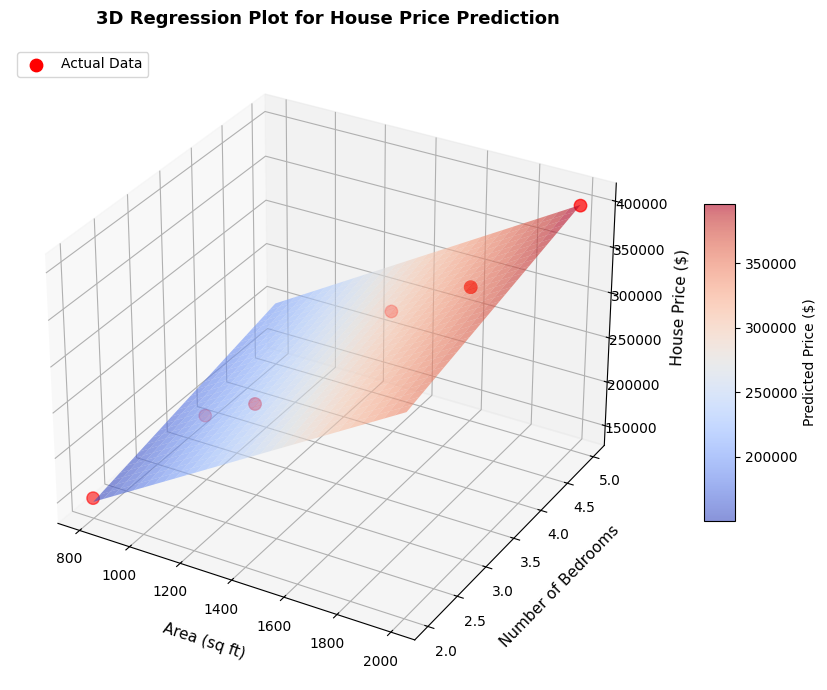

In [ ]:
data = {
    "Area": [800, 1000, 1200, 1500, 1800, 2000],
    "Bedrooms": [2, 3, 3, 4, 4, 5],
    "Price": [150000, 200000, 230000, 300000, 350000, 400000],
}

df = pd.DataFrame(data)

print(df.head())
print(f"\nShape: {df.shape}")
df.info()
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

X = df[["Area", "Bedrooms"]]
y = df["Price"]

# fit scaler on the full dataset before splitting (small demo dataset)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nIntercept        : {model.intercept_:.2f}")
print(f"Coeff (Area)     : {model.coef_[0]:.2f}")
print(f"Coeff (Bedrooms) : {model.coef_[1]:.2f}")

y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"\nMSE : {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": np.round(y_pred, 2)
})
print("\nPrediction Results:")
print(results.to_string(index=False))

# build a meshgrid in original feature space, scale before predicting
area_range    = np.linspace(X["Area"].min(),     X["Area"].max(),     30)
bedroom_range = np.linspace(X["Bedrooms"].min(), X["Bedrooms"].max(), 30)

area_grid, bedroom_grid = np.meshgrid(area_range, bedroom_range)

grid_points = pd.DataFrame({
    "Area": area_grid.ravel(),
    "Bedrooms": bedroom_grid.ravel()
})

grid_scaled = scaler.transform(grid_points)
price_grid  = model.predict(grid_scaled).reshape(area_grid.shape)

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["Area"], df["Bedrooms"], df["Price"],
    color="red", s=80, zorder=5, label="Actual Data"
)

surf = ax.plot_surface(
    area_grid, bedroom_grid, price_grid,
    alpha=0.6, cmap="coolwarm", edgecolor="none"
)

ax.set_xlabel("Area (sq ft)",       fontsize=11, labelpad=10)
ax.set_ylabel("Number of Bedrooms", fontsize=11, labelpad=10)
ax.set_zlabel("House Price ($)",    fontsize=11, labelpad=10)

ax.set_title(
    "3D Regression Plot for House Price Prediction",
    fontsize=13, fontweight="bold", pad=15
)

fig.colorbar(surf, shrink=0.5, aspect=10, label="Predicted Price ($)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()